## HAVEN Probability Distributions for Invertebrate Animal Sequences

The below analysis was conducted following adapting a config file and running an experiment using HAVEN given viruses that infect only invertebrate animals.

### Loading data and importing libraries

In [1]:
# import appropriate directories for analysis
import pandas as pd
import os
from ete3 import NCBITaxa
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec
import numpy as np
from scipy.stats import entropy

file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "output/raw/uniref90-common-hosts/invertebrates/msl256ae_bn_vs30cls_s64.csv")
df = pd.read_csv(file_path)
df

,uniref90_id,Capybara,Himalayan marmot,Human,Pig,Red junglefowl,y_true
0,UniRef90_A0A023JGD9,0.000108,0.000550,0.172921,0.822747,0.003674,Culex sp.
1,UniRef90_A0A023NFV2,0.001698,0.005949,0.223424,0.759602,0.009327,Spodoptera exigua
2,UniRef90_A0A023NG79,0.028871,0.003207,0.743845,0.215413,0.008663,Spodoptera exigua
3,UniRef90_A0A023NHN1,0.107967,0.500862,0.246701,0.128388,0.016081,Spodoptera exigua
4,UniRef90_A0A023Q224,0.069840,0.073275,0.383435,0.472066,0.001384,Culex quinquefasciatus
...,...,...,...,...,...,...,...
12895,UniRef90_X5GYB4,0.002822,0.016178,0.285745,0.694265,0.000990,Nilaparvata lugens
12896,UniRef90_X5GYB7,0.006420,0.000941,0.775889,0.206888,0.009863,Nilaparvata lugens
12897,UniRef90_X5GYC1,0.022396,0.002684,0.338583,0.625867,0.010470,Nilaparvata lugens
12898,UniRef90_X5I2I8,0.004310,0.011765,0.739691,0.197046,0.047187,Nilaparvata lugens


In [2]:
# prints the number of unique invertebrate animal hosts
len(df['y_true'].value_counts())

813

The dataset comprises 12,900 invertebrate animal hosts, representing a curated subset of the original UniRef90 collection, which contains 80,536 invertebrates.

In [3]:
file_path = os.path.join(os.getcwd(), "..", "..", "..","..", "output/raw/uniref90-common-hosts/plants/mlm_tfenc_l6_h8_lr1e-4_uniref90viridae_msl256s64allemb_vs30cls_batchnorm_hybrid_attention_msl256s64ae_fnn_2l_d1024_lr1e-4_output.csv")
vert_df = pd.read_csv(file_path)
vert_df

,Unnamed: 0,Capybara,Himalayan marmot,Human,Pig,Red junglefowl,y_true,itr
0,0,0.034830,0.003839,0.866651,0.008842,0.085837,Human,0
1,1,0.002989,0.002727,0.486508,0.491108,0.016668,Human,0
2,2,0.005151,0.001573,0.842814,0.113344,0.037117,Human,0
3,3,0.018767,0.003496,0.647620,0.002375,0.327742,Human,0
4,4,0.000142,0.001743,0.581591,0.396647,0.019876,Human,0
...,...,...,...,...,...,...,...,...
15840,3164,0.019616,0.013855,0.717673,0.116417,0.132440,Human,4
15841,3165,0.000357,0.000074,0.209644,0.047748,0.742176,Human,4
15842,3166,0.002599,0.003074,0.840193,0.144701,0.009434,Human,4
15843,3167,0.026969,0.019138,0.898321,0.051312,0.004261,Human,4


### Exploratory Data Analysis on Five Common Hosts

The following analysis shows the maximum probabilities for each of the five common hosts given all 12900 rows and the associated invertebrate animal host. Probabilities closer to 1 show higher confidence in HAVEN's prediction.

In [4]:
idx = df.Capybara.idxmax()
df.loc[idx]

uniref90_id           UniRef90_W5U1V9
Capybara                     0.981584
Himalayan marmot             0.001193
Human                        0.003222
Pig                          0.001517
Red junglefowl               0.012484
y_true              Procordulia grayi
Name: 12437, dtype: object

This specific viral protein sequence infects Procordulia grayi, which is a gray's dragonfly. HAVEN predicts the host is Capybara with roughly 98% probability.

In [5]:
idx = df['Himalayan marmot'].idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A346TPS4
Capybara                       0.002136
Himalayan marmot               0.991343
Human                          0.005693
Pig                            0.000306
Red junglefowl                 0.000523
y_true               Mythimna unipuncta
Name: 4377, dtype: object

This specific viral protein sequence infects Mythimna unipuncta, which is the Armyworm moth. HAVEN predicts the host is Himalayan marmot with roughly 99% probability.

In [6]:
idx = df['Human'].idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A2D3I6L1
Capybara                       0.002444
Himalayan marmot               0.002358
Human                          0.986332
Pig                              0.0008
Red junglefowl                 0.008065
y_true                  Penaeus monodon
Name: 2041, dtype: object

This specific viral protein sequence infects Penaeus monodon, which is the giant tiger prawn. HAVEN predicts the host is Human with roughly 99% probability.

In [7]:
idx = df['Pig'].idxmax()
df.loc[idx]

uniref90_id         UniRef90_A0A0K1Y867
Capybara                            0.0
Himalayan marmot               0.002494
Human                          0.006892
Pig                              0.9904
Red junglefowl                 0.000214
y_true                   Apis mellifera
Name: 652, dtype: object

This specific viral protein sequence infects Apis mellifera, which is the western honey bee. HAVEN predicts the host is Pig with roughly 99% probability.

In [8]:
idx = df['Red junglefowl'].idxmax()
df.loc[idx]

uniref90_id              UniRef90_A0A4P8PJY3
Capybara                            0.001624
Himalayan marmot                    0.000026
Human                               0.004186
Pig                                 0.000003
Red junglefowl                      0.994161
y_true              Austrosimulium ungulatum
Name: 5183, dtype: object

This specific viral protein sequence infects Austrosimulium ungulatum, which is the west coast black fly. HAVEN predicts the host is Red junglefowl with roughly 99% probability.

**Quantitative Analysis**: The percentages below represent the number of sequences that HAVEN predicts as a particular host with a probability of greater than 0.5 divided by the total number of sequences. This shows which host has a greater percentage of higher probabilities.

In [9]:
print(str(round((len(df[df['Capybara'] > 0.5]) / len(df)) * 100, 2)) + "%")

10.84%


In [10]:
print(str(round((len(df[df['Himalayan marmot'] > 0.5]) / len(df)) * 100, 2)) + "%")

1.31%


In [11]:
print(str(round((len(df[df['Human'] > 0.5]) / len(df)) * 100, 2)) + "%")

32.09%


In [12]:
print(str(round((len(df[df['Pig'] > 0.5]) / len(df)) * 100, 2)) + "%")

21.08%


In [13]:
print(str(round((len(df[df['Red junglefowl'] > 0.5]) / len(df)) * 100, 2)) + "%")

11.88%


HAVEN predicts Human as the host with higher than 0.5 probability roughly 32.09% of the time for invertebrate animal sequences, which is about 3 times more than Capybara and 3 times more than Red junglefowl.

### Graphics for Probability Distributions

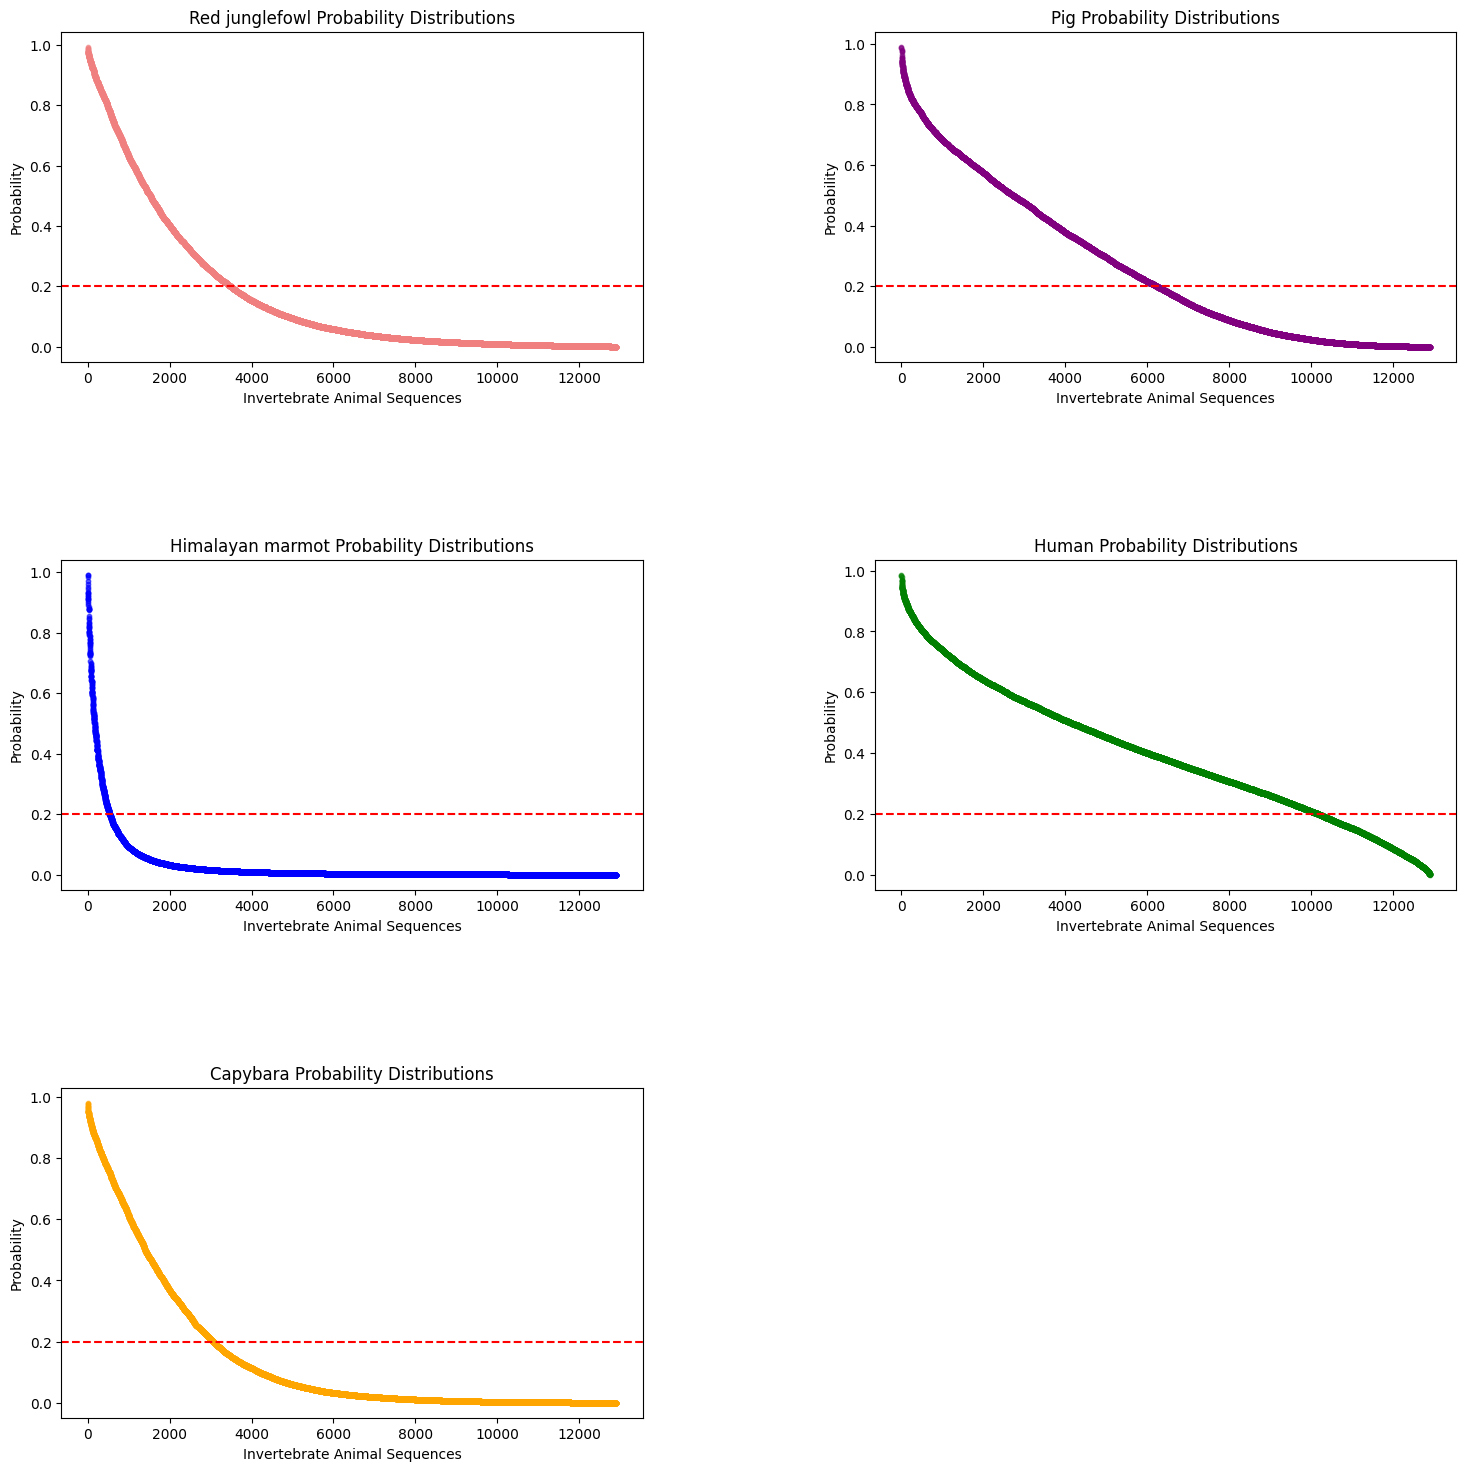

In [14]:
plt.figure(figsize=(18, 18))
plt.subplots_adjust(wspace=0.4, hspace=0.6)

threshold = 0.01
hosts = ['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']
colors = ['lightcoral', 'purple', 'blue', 'green', 'orange']

for i, (host, color) in enumerate(zip(hosts, colors)):
    plt.subplot(3, 2, i + 1)
    
    y_vals = df[host].sort_values(ascending=False).values
    x_vals = range(len(y_vals))
    
    plt.scatter(x_vals, y_vals, color=color, label=host, s=10, alpha=0.6)
    plt.title(f'{host} Probability Distributions')
    plt.xlabel('Invertebrate Animal Sequences')
    plt.ylabel('Probability')
    plt.axhline(y=0.2, color='r', linestyle='--')

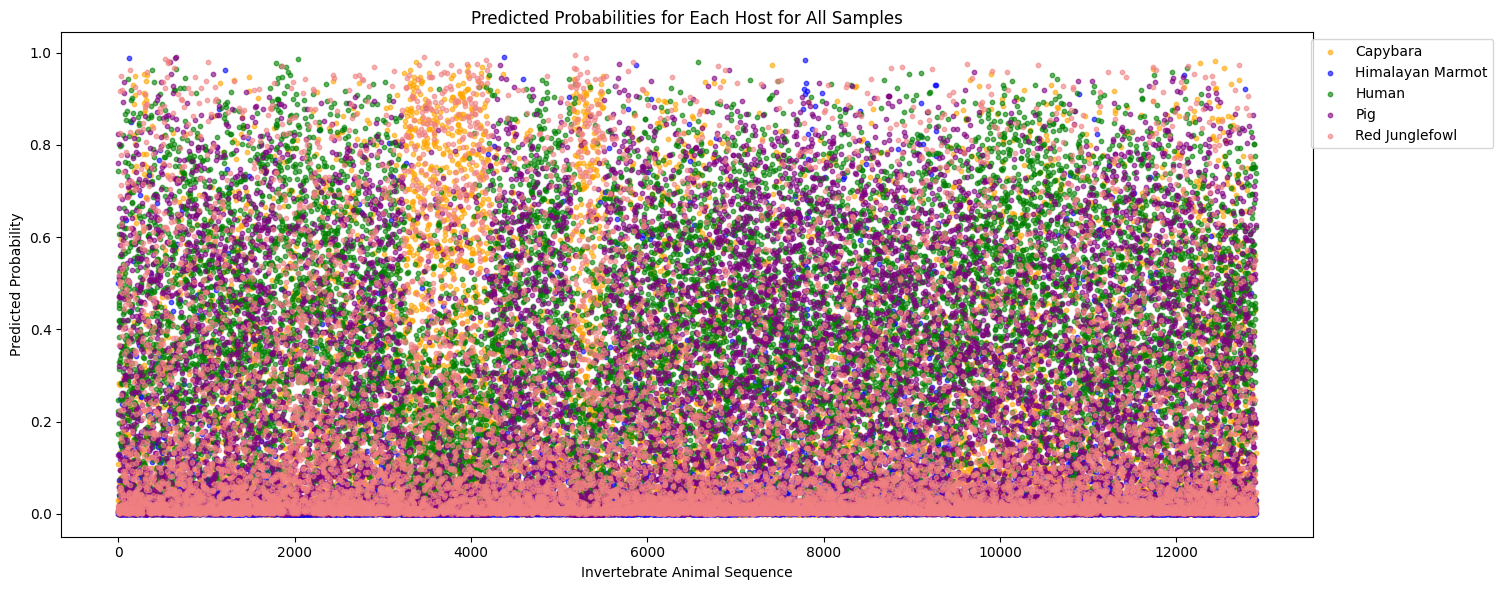

In [15]:
plt.figure(figsize=(15, 6))

x = df.index

# plot each host's probability as colored dots
plt.scatter(x, df['Capybara'], color='orange', label='Capybara', s=10, alpha=0.6)
plt.scatter(x, df['Himalayan marmot'], color='blue', label='Himalayan Marmot', s=10, alpha=0.6)
plt.scatter(x, df['Human'], color='green', label='Human', s=10, alpha=0.6)
plt.scatter(x, df['Pig'], color='purple', label='Pig', s=10, alpha=0.6)
plt.scatter(x, df['Red junglefowl'], color='lightcoral', label='Red Junglefowl', s=10, alpha=0.6)

# add labels, legend, title
plt.title('Predicted Probabilities for Each Host for All Samples')
plt.xlabel('Invertebrate Animal Sequence')
plt.ylabel('Predicted Probability')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.tight_layout()
plt.show()

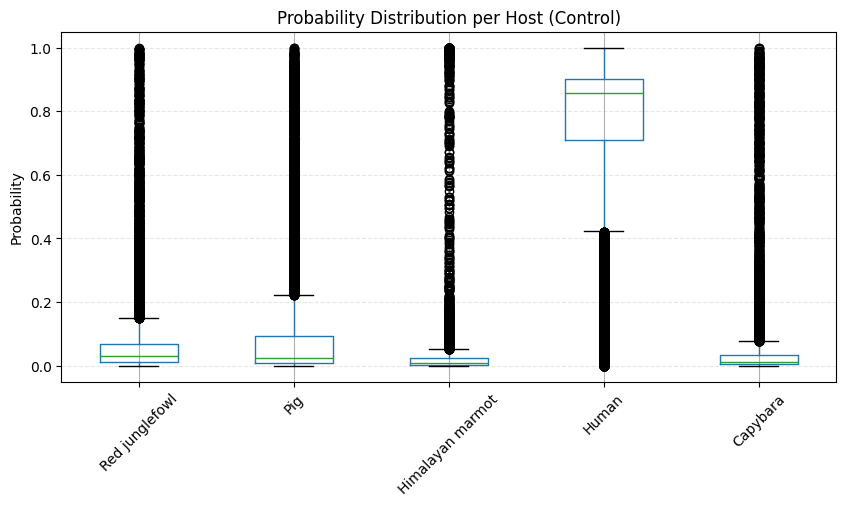

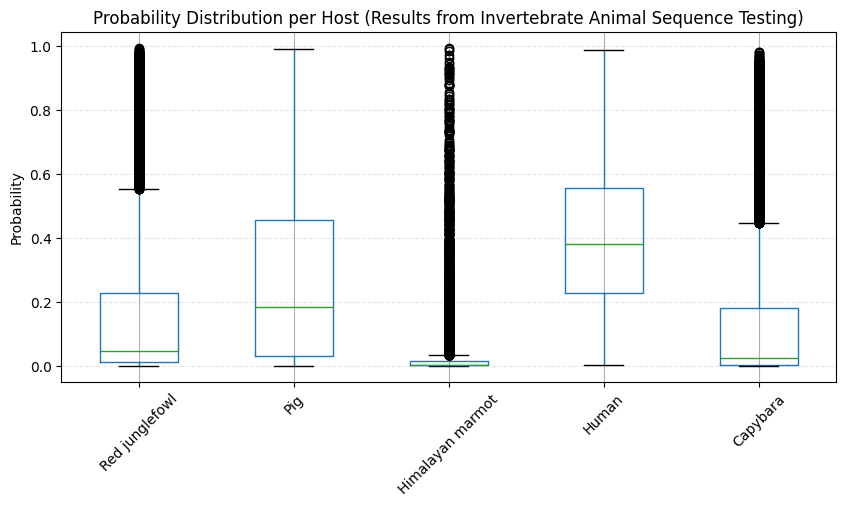

In [16]:
# box plots for control (haven trained on uniref90 filtered for vertebrate sequences)
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 1)
vert_df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']].boxplot()
plt.ylabel("Probability")
plt.title("Probability Distribution per Host (Control)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

# box plots for plant sequence testing (experimenting on haven with unseen hosts/potentially unseen viruses as well)
plt.figure(figsize=(10, 10))
plt.subplot(2, 1, 2)
df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']].boxplot()
plt.ylabel("Probability")
plt.title("Probability Distribution per Host (Results from Invertebrate Animal Sequence Testing)")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.3)

As shown in the above box plots displaying the probability distributions for the five common hosts, Himalayan marmot, Red junglefowl, and Capybara exhibit a right skewed distribution, where most of the probabilities fall below 0.1 for the latter two. The Human host distribution has a mean of roughly 0.4 and displays a more normal distribution than its counterparts. The greater difference in the distributions between the control and the invertebrate animal sequence testing indicates that HAVEN is more confused.

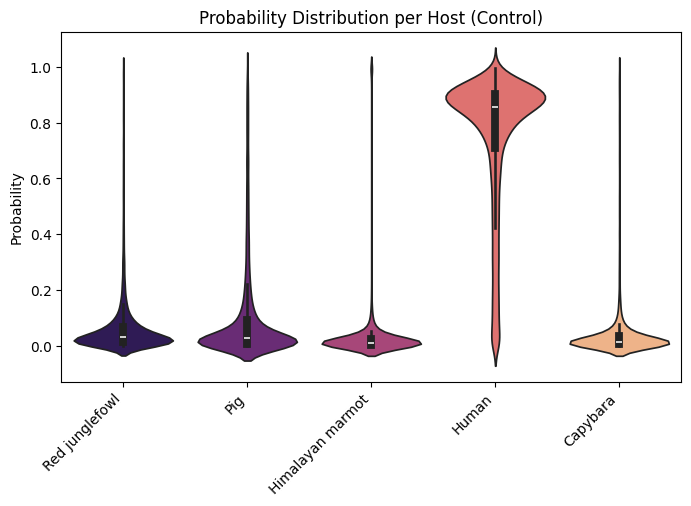

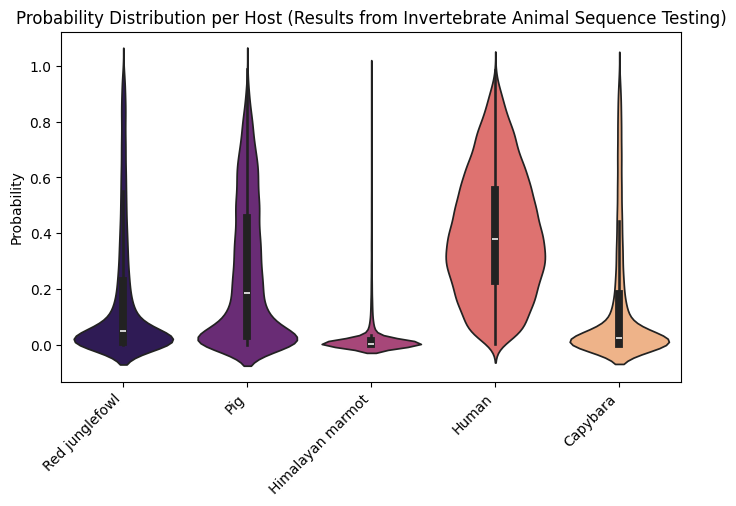

In [17]:
# same concept as above, however different visualization (violin plots)
plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 1)
sns.violinplot(vert_df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']], palette='magma')
plt.title('Probability Distribution per Host (Control)')
plt.ylabel('Probability')
plt.xticks(ha='right', rotation=45)
plt.show()

plt.figure(figsize=(8, 10))
plt.subplot(2, 1, 2)
sns.violinplot(df[['Red junglefowl', 'Pig', 'Himalayan marmot', 'Human', 'Capybara']], palette='magma')
plt.title('Probability Distribution per Host (Results from Invertebrate Animal Sequence Testing)')
plt.ylabel('Probability')
plt.xticks(ha='right', rotation=45)
plt.show()

### Statistical Analysis

##### Computing Summary Statistics & Visualizing Uncertainty via Entropy

In [18]:
# compute summary stats
def compute_stats(df, group_name, hosts):
    means = df[hosts].mean()
    stds = df[hosts].std()
    summary = means.round(3).astype(str) + " ± " + stds.round(3).astype(str)
    return pd.DataFrame({'Mean ± Std': summary}, index=hosts).rename(columns={'Mean ± Std': group_name})

stats = compute_stats(df, "Invertebrate", hosts)
summary_table = pd.concat([stats], axis=1)
print(summary_table)

                   Invertebrate
Red junglefowl    0.166 ± 0.236
Pig                0.26 ± 0.251
Himalayan marmot  0.032 ± 0.098
Human             0.398 ± 0.218
Capybara           0.145 ± 0.23


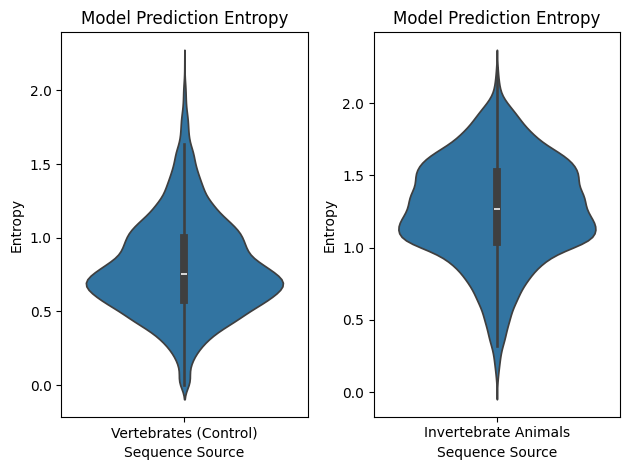

In [19]:
# define entropy function (measures the uncertainty in HAVEN's predicted host probabilities for a given viral sequencce)
# low entropy means max confidence, high means uncertain between 2 classes, outlier means maximum confusion
def add_entropy_column(df, hosts):
    df = df.copy()
    df['entropy'] = df[hosts].apply(lambda row: entropy(row.values, base=2), axis=1)
    return df

df_inv = add_entropy_column(df, hosts)
df_inv['group'] = 'Invertebrate Animals'

df_vert = add_entropy_column(vert_df, hosts)
df_vert['group'] = 'Vertebrates (Control)'

plt.subplot(1, 2, 1)
sns.violinplot(data=df_vert, x='group', y='entropy')
plt.title("Model Prediction Entropy")
plt.xlabel("Sequence Source")
plt.ylabel("Entropy")

plt.subplot(1, 2, 2)
sns.violinplot(data=df_inv, x='group', y='entropy')
plt.title("Model Prediction Entropy")
plt.xlabel("Sequence Source")
plt.ylabel("Entropy")

plt.tight_layout()
plt.show()

In [20]:
entropy_stats = df_inv.groupby('group')['entropy'].describe()
print(entropy_stats)

                        count      mean       std       min       25%  \
group                                                                   
Invertebrate Animals  12900.0  1.262245  0.355257  0.056965  1.040587   

                           50%       75%       max  
group                                               
Invertebrate Animals  1.264307  1.522124  2.261753  


It is reasonable that the average entropy for these data is between 1 to 1.5. HAVEN is moderately uncertain, however it is seeing some familiar patterns in these sequences and shared protein motifs among vertebrate hosts.

**Note**: scipy.stats.entropy function calculates Shannon entropy (H = - Σ (pk * log(pk)))

### Predictive Trends
##### Does HAVEN classify certain plant hosts repeatedly as the same host or assign different hosts (from the five common hosts) in multiple instances?

In [21]:
# get the predicted host with the highest probability for each row
df['Top_Host'] = df[hosts].idxmax(axis=1)

results = []

# create columns for storing plant host, if its always the same host, top host, and the number of sequences
for animal in df['y_true'].unique():
    subset = df[df['y_true'] == animal]
    top_host = subset['Top_Host'].iloc[0]
    always_same = (subset['Top_Host'] == top_host).all()
    
    results.append({
        'Invertebrate': animal,
        'Always_Same_Host': always_same,
        'Top_Host': top_host,
        'Num_Sequences': len(subset)
    })

# convert results into data frame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='Num_Sequences', ascending=False)

print(results_df)

              Invertebrate  Always_Same_Host        Top_Host  Num_Sequences
255          Ciona robusta             False        Capybara            970
30         Penaeus monodon             False           Human            623
211       Penaeus vannamei             False  Red junglefowl            570
5           Apis mellifera             False           Human            469
167     Mythimna unipuncta             False        Capybara            439
..                     ...               ...             ...            ...
323   Macropsylla hercules              True             Pig              1
318    Acyrthosiphon pisum              True             Pig              1
316         Rachiplusia nu              True             Pig              1
315  Phlebotomus neglectus              True             Pig              1
812       Heliconius erato              True             Pig              1

[813 rows x 4 columns]


In [22]:
print("There are " + str(len(results_df[(results_df['Always_Same_Host'] == True) & (results_df['Num_Sequences'] > 1)])) + " unique invertebrate animals where HAVEN predicts the same host for every instance in the dataset.")

There are 70 unique invertebrate animals where HAVEN predicts the same host for every instance in the dataset.


/localscratch/ipykernel_829694/2174046843.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_host_counts.index, y=top_host_counts.values, palette='magma')


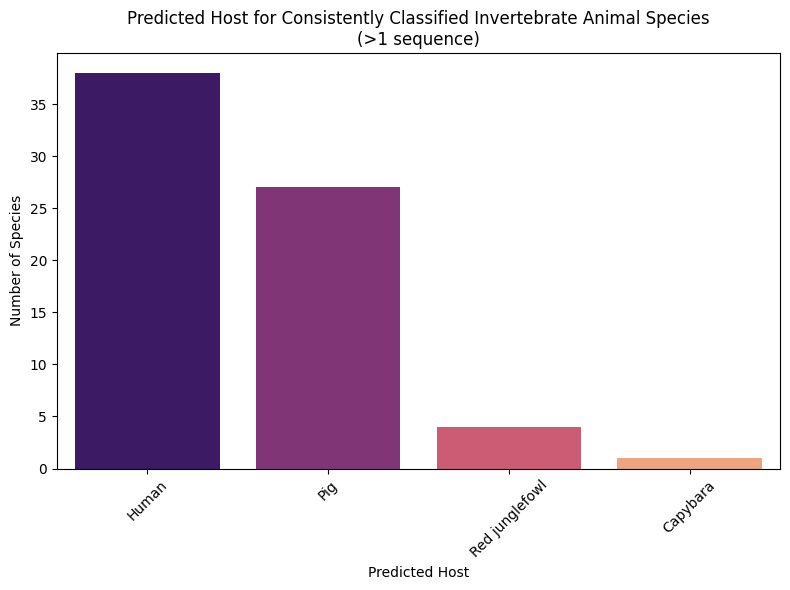

In [23]:
# defined a "consistent prediction" when it is predicting the same host for more than 1 sequencce
consistent_predictions = results_df[
    (results_df['Always_Same_Host'] == True) &
    (results_df['Num_Sequences'] > 1)
]

# count top predicted hosts
top_host_counts = consistent_predictions['Top_Host'].value_counts()

# plot, add title and axis labels
plt.figure(figsize=(8,6))
sns.barplot(x=top_host_counts.index, y=top_host_counts.values, palette='magma')

plt.title('Predicted Host for Consistently Classified Invertebrate Animal Species\n(>1 sequence)')
plt.xlabel('Predicted Host')
plt.ylabel('Number of Species')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

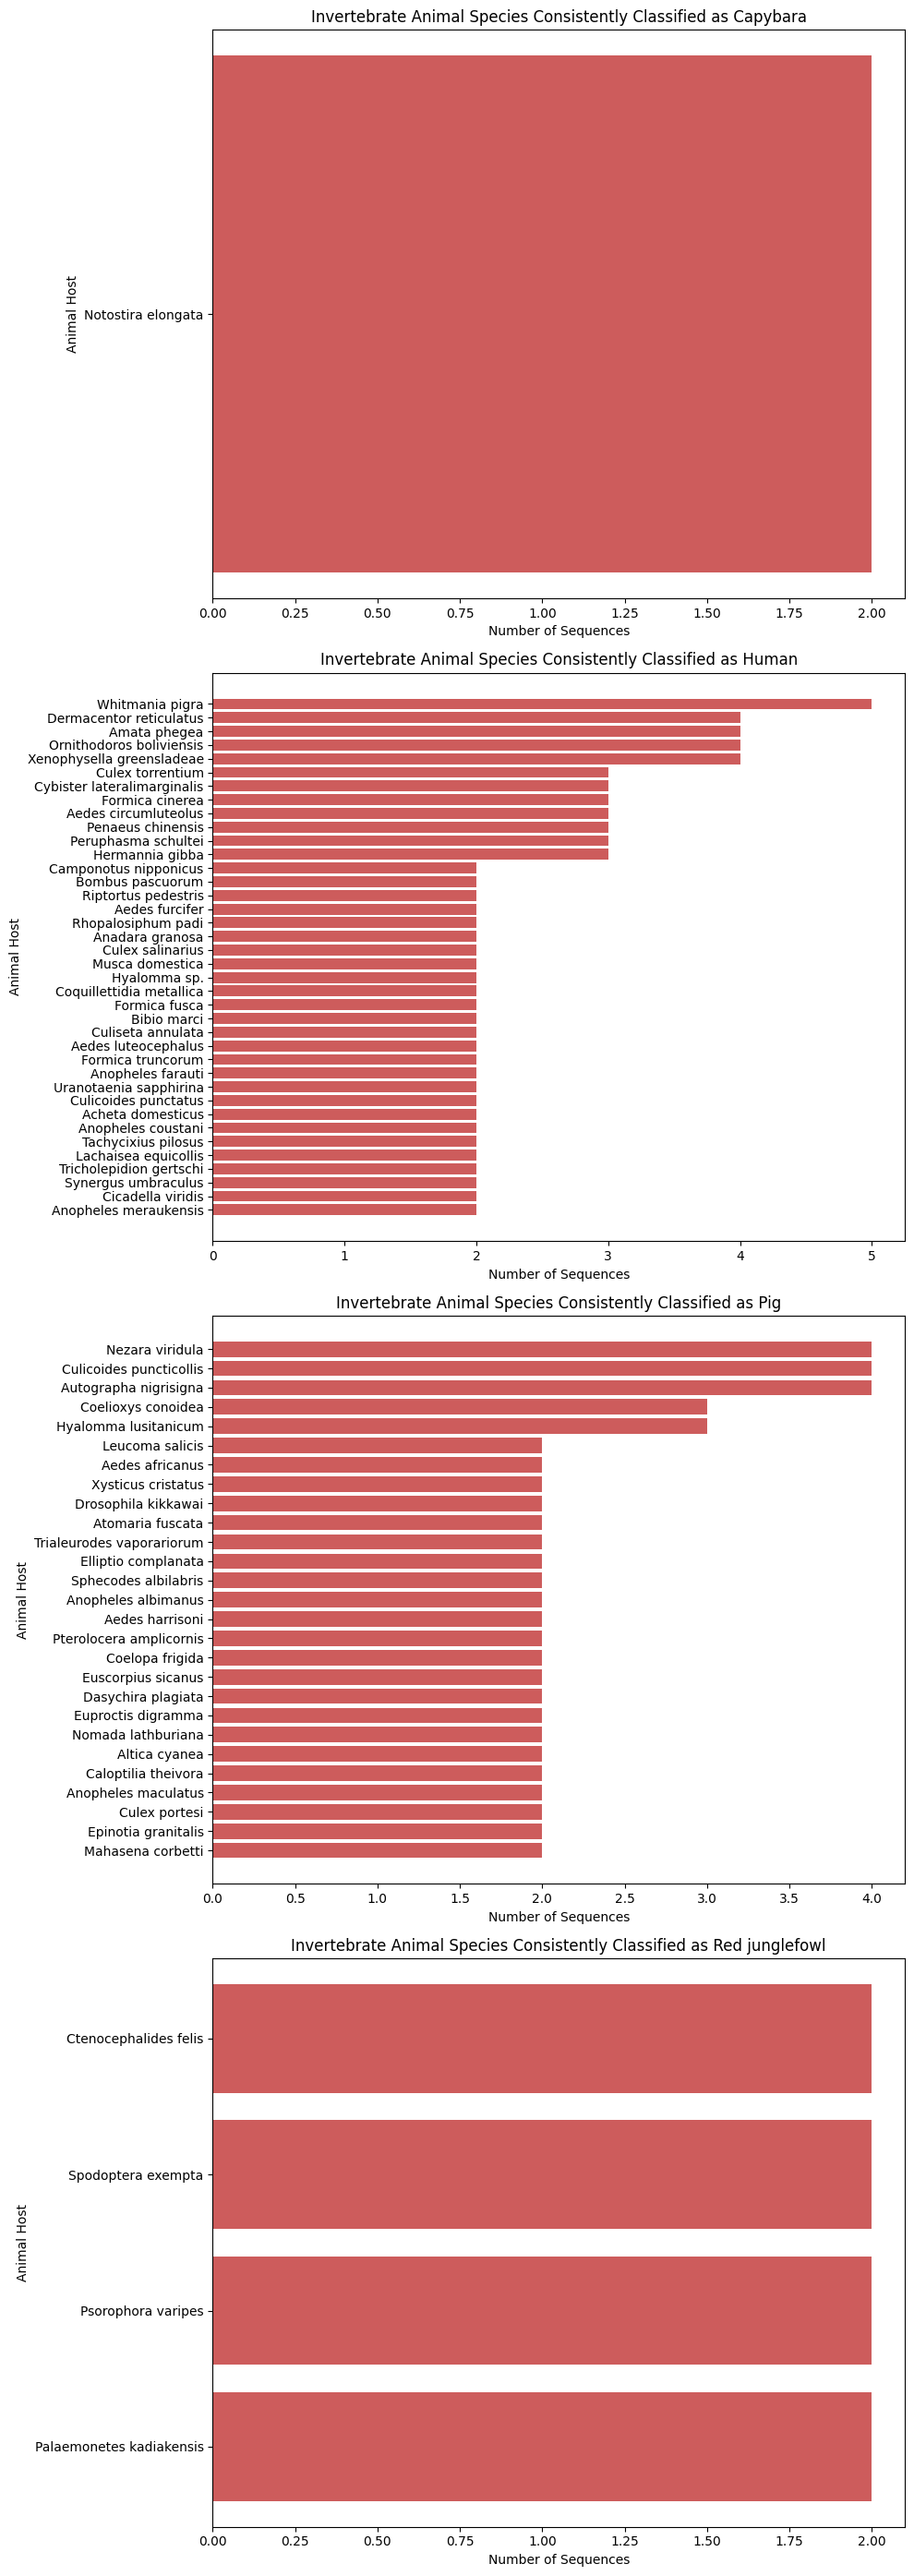

In [24]:
grouped = consistent_predictions.groupby('Top_Host')
hosts = grouped.groups.keys()
n_hosts = len(hosts)

# create subplots
fig, axes = plt.subplots(n_hosts, 1, figsize=(10, 7 * n_hosts), sharex=False)

if n_hosts == 1:
    axes = [axes]

# function to retrieve actual plant host from the consistently predicted five common hosts
for ax, host in zip(axes, hosts):
    group = grouped.get_group(host).sort_values(by='Num_Sequences', ascending=False)
    plant_names = group['Invertebrate']
    counts = group['Num_Sequences']
    
    ax.barh(plant_names, counts, color='indianred')
    ax.set_title(f'Invertebrate Animal Species Consistently Classified as {host}')
    ax.set_xlabel('Number of Sequences')
    ax.set_ylabel('Animal Host')
    ax.invert_yaxis()

plt.tight_layout()
plt.show()

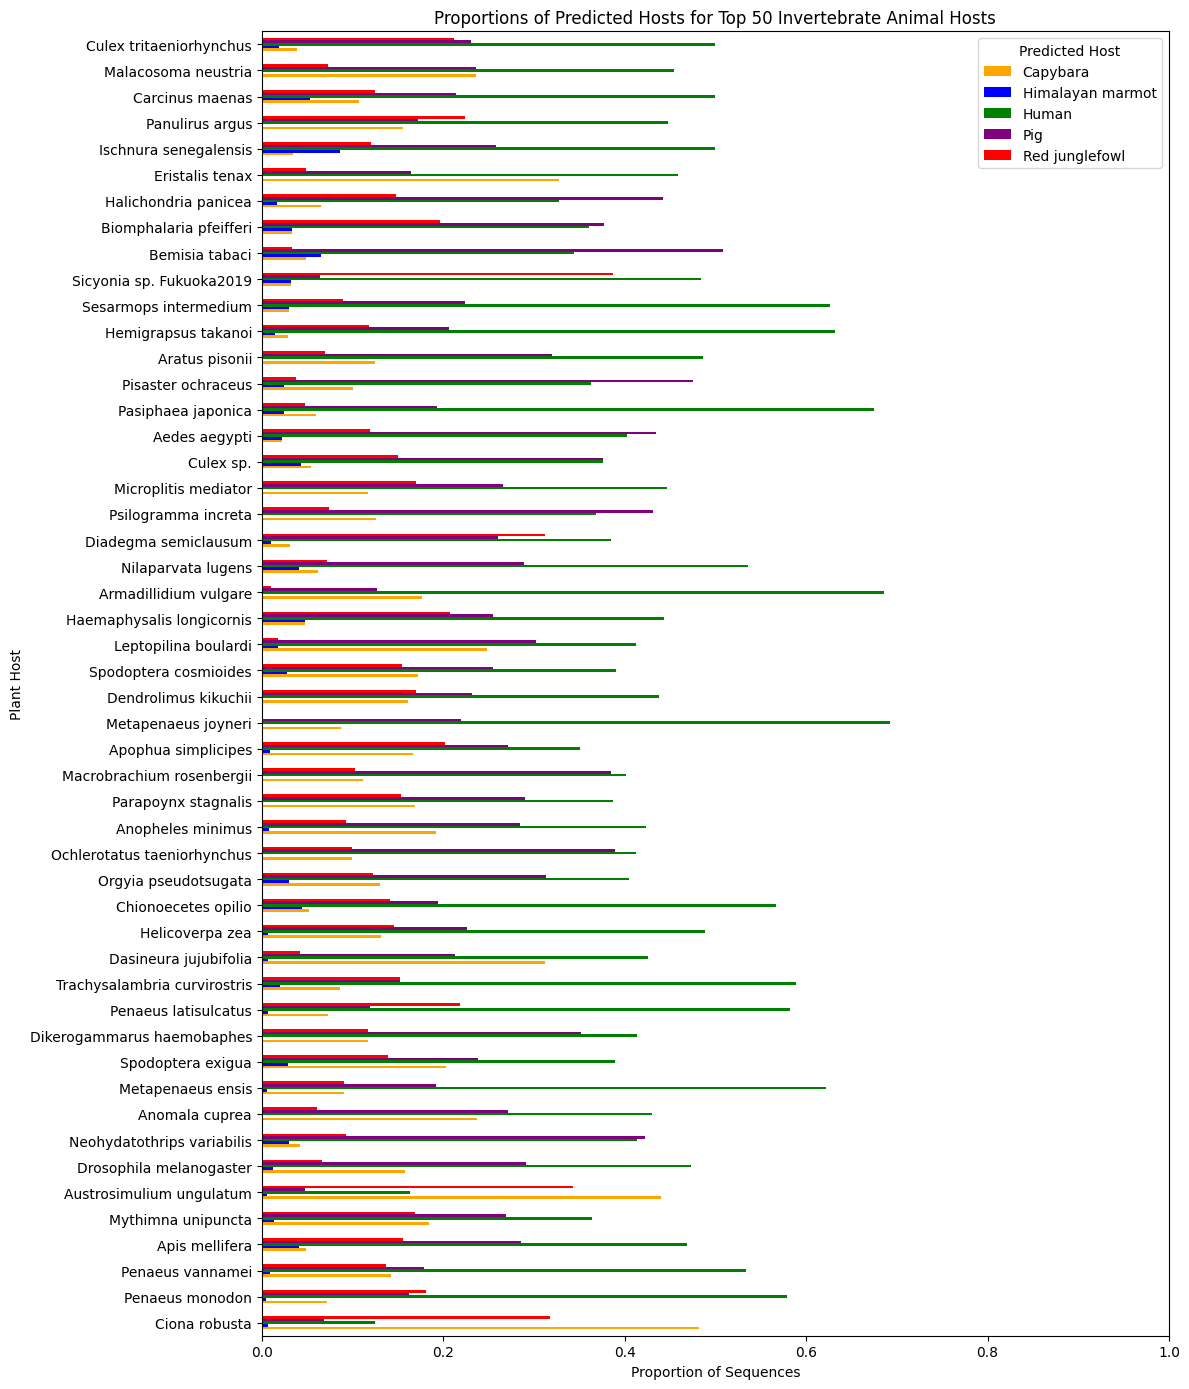

In [25]:
# get the top 50 most prevalent invertebrate animals in the dataset (out of 911 total unique invertebrate animal hosts)
top_50_plants = df['y_true'].value_counts().head(50).index
filtered_df = df[df['y_true'].isin(top_50_plants)].copy()

# count how many invertebrate animal sequences were reported as a specific host (of the five common hosts)
counts = filtered_df.groupby(['y_true', 'Top_Host']).size().reset_index(name='count')

# count the total number of sequences for each invertebrate host
total_per_plant = filtered_df.groupby('y_true').size().reset_index(name='total')

# perform a merge to combine two datasets (one containing the counts and the other number of sequences) together on the y_true column
# create a proportion column that divides count by total number of sequences
merged = counts.merge(total_per_plant, on='y_true')
merged['proportion'] = merged['count'] / merged['total']

# pivot/rotate the table so that y_true is the index and columns are Top_Host, values are the proportion
pivot_df = merged.pivot(index='y_true', columns='Top_Host', values='proportion').fillna(0)
pivot_df = pivot_df.loc[top_50_plants]

# plot the horizontal bar plot showing five bars for each plant host
ax = pivot_df.plot(
    kind='barh',
    stacked=False,
    figsize=(12, 14),
    color={
        'Capybara': 'orange',
        'Himalayan marmot': 'blue',
        'Human': 'green',
        'Pig': 'purple',
        'Red junglefowl': 'red',
    }
)

# configure the barplots to one graph display
plt.xlabel('Proportion of Sequences')
plt.xlim(0, 1)
plt.ylabel('Plant Host')
plt.title('Proportions of Predicted Hosts for Top 50 Invertebrate Animal Hosts')
plt.legend(title='Predicted Host', loc='upper right')

plt.tight_layout()
plt.show()

**Bar Chart Analysis:**
* Metapenaeus joyneri (shiba shrimp) highest proportion of sequences predicted as Human
* Bemisia tabaci (silverleaf whitefly) highest proportion of sequences predicted as Pig
* Ciona robusta (marine invertebrate) highest proportion of sequences predicted as Capybara
* Sicyonia sp. Fukuoka2019 (type of prawn, crustacean) highest proportion of sequences predicted as Red junglefowl
* Ischnura senegalensis (damselfly) highest proportion of sequences predicted as Himalayan marmot

**Note:** idxmax function was used to retrieve the largest proportions for each of the five common hosts, therefore some hosts listed above do not appear on the bar chart graph

### Observations & Conclusions

The results show that HAVEN does decently well in predicting the host given the viral protein sequences of invertebrate animal virus', ones it has not seen before in training. We expect that the model acts 'confused' when given these invertebrata sequences and by the violin plot we notice the 'confusion' due to the increased range of probabilities and wider distributions. HAVEN might be seeing more sequence similarity with the invertebrate animal hosts, so it displays more confidence in certain areas than with plant hosts.

Some interesting findings throughout the exploratory process include Whitmania pigra (freshwater leech) was misinterpreted as a Human five times, the highest number of all misclassifications. HAVEN consistently predicts the host as a Human, which could be potentially due to more extensive and comprehensive training data for human virus'. Another surprising finding is that HAVEN is confident that a majority of these viral protein sequences do not infect Himalayan marmots, a finding supported in the plant sequence experiment, which could be due to limited data in that area, but also indicative of HAVEN's ability to make accurate and confident predictions.